In [18]:
import numpy as np
import pyshtools as pysh
import boule as bl
import pandas as pd
import xarray as xr
import harmonica as hm
import verde as vd
from pathlib import Path

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.patches as mpatches

In [26]:
def carplot(da, title="", cbar_label="", cmap="jet", filename=None,
            projection="robinson"):
    """
    支持多种投影的全球绘图函数。
    projection 可选: "mollweide"（默认）、"robinson"、"platecarree"
    """
    proj_map = {
        "mollweide":   ccrs.Mollweide(),
        "robinson":    ccrs.Robinson(),
        "platecarree": ccrs.PlateCarree(),
    }
    proj = proj_map.get(projection.lower(), ccrs.Mollweide())

    lon = da["lon"].values.astype(float)
    lat = da["lat"].values.astype(float)
    data = da.values

    # wrap 0..360 -> [-180, 180)
    if np.nanmax(lon) > 180:
        lon_wrapped = ((lon + 180) % 360) - 180
        idx = np.argsort(lon_wrapped)
        lon_plot = lon_wrapped[idx]
        data_plot = data[:, idx]
    else:
        lon_plot = lon
        data_plot = data

    fig = plt.figure(figsize=(10, 5), dpi=150)
    ax = plt.axes(projection=proj)
    ax.set_global()   # 替代 set_extent，适用于所有投影

    # Mollweide/Robinson 不支持 draw_labels=True，需要手动关掉
    gl = ax.gridlines(
        draw_labels=(projection.lower() == "platecarree"),
        linewidth=0.5, linestyle="--", alpha=0.5
    )
    if projection.lower() == "platecarree":
        gl.top_labels = False
        gl.right_labels = False

    mesh = ax.pcolormesh(
        lon_plot, lat, data_plot,
        transform=ccrs.PlateCarree(),   # 数据坐标系始终是 PlateCarree
        shading="auto",
        cmap=cmap
    )

    ax.set_title(title)
    cbar = plt.colorbar(mesh, ax=ax, shrink=0.85, pad=0.05,
                        orientation="horizontal")  # 水平 colorbar 更配椭圆投影
    if cbar_label:
        cbar.set_label(cbar_label)

    plt.tight_layout()
    if filename:
        plt.savefig(filename, bbox_inches="tight")
    plt.show()
    return fig, ax


def carplot_basins(da, basins, save_path=None, title="",
                   cbar_label="Bouguer gravity anomaly (mGal)", cmap="jet",
                   projection="mollweide"):
    lon = da["lon"].values.astype(float)
    lat = da["lat"].values.astype(float)
    data = da.values

    proj_map = {
        "mollweide":   ccrs.Mollweide(),
        "robinson":    ccrs.Robinson(),
        "platecarree": ccrs.PlateCarree(),
    }
    proj = proj_map.get(projection.lower(), ccrs.Mollweide())

    if np.nanmax(lon) > 180:
        lon_wrapped = ((lon + 180) % 360) - 180
        idx = np.argsort(lon_wrapped)
        lon_plot = lon_wrapped[idx]
        data_plot = data[:, idx]
    else:
        lon_plot = lon
        data_plot = data

    fig = plt.figure(figsize=(10, 5), dpi=150)
    ax = plt.axes(projection=proj)
    ax.set_global()

    ax.gridlines(
        draw_labels=(projection.lower() == "platecarree"),
        linewidth=0.5, linestyle="--", alpha=0.5
    )

    mesh = ax.pcolormesh(
        lon_plot, lat, data_plot,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap=cmap
    )

    cbar = plt.colorbar(mesh, ax=ax, shrink=0.85, pad=0.05,
                        orientation="horizontal")
    if cbar_label:
        cbar.set_label(cbar_label)

    # 盆地圆圈
    R_moon_km = bl.Moon2015.mean_radius * 1e-3
    for name, lat_c, lon_c, radius_km in basins:
        ang_deg = np.rad2deg(radius_km / R_moon_km)

        circ = mpatches.Circle(
            (lon_c, lat_c),
            radius=ang_deg,
            transform=ccrs.PlateCarree(),
            fill=False,
            linewidth=1.0,
            edgecolor="black",
            zorder=5,
        )
        ax.add_patch(circ)

        ax.text(
            lon_c, lat_c, name,
            transform=ccrs.PlateCarree(),
            ha="center", va="center",
            fontsize=8, fontweight="bold",
            color="black", zorder=6
        )

    if title:
        ax.set_title(title)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"图已保存至: {save_path}")
    plt.show()
    return fig, ax

In [20]:
PROJECT_ROOT = Path.cwd().parent
data_filename=PROJECT_ROOT/"data/boueguer_frenquency_11km_1deg.csv"
result_filename=PROJECT_ROOT/"data/boueguer_frenquency_11km_d35km_1deg.csv"
height=11e3
crust_thick=30e3                    # 月壳平均厚度

In [21]:
lmax=719
# 密度
densityfile = PROJECT_ROOT/"data/density_no_mare_n3000_f3050_719.sh"
density = pysh.SHCoeffs.from_file(densityfile, lmax=lmax)
density_grid=density.expand(grid='DH2',lmax=lmax,extend=False)
density_xr=density_grid.to_xarray()
weights = np.cos(np.deg2rad(density_xr.lat))
density_xr_anomaly = density_xr - density_xr.weighted(weights).mean(("lat", "lon"))
# 重力
pot=pysh.datasets.Moon.GRGM1200B()
pot.set_omega(bl.Moon2015.angular_velocity)
pot=pot.change_ref(gm=bl.Moon2015.geocentric_grav_const, r0=bl.Moon2015.radius)
pot_grid= pot.expand(lmax=lmax, a=bl.Moon2015.radius + height, f=0, normal_gravity=False, extend=False)
pot_xr=pot_grid.to_xarray()
# 地形
topo=pysh.datasets.Moon.LDEM_shape_pa()
topo_grid=topo.expand(grid='DH2',lmax=lmax,extend=False)
topo_xr=topo_grid.to_xarray()

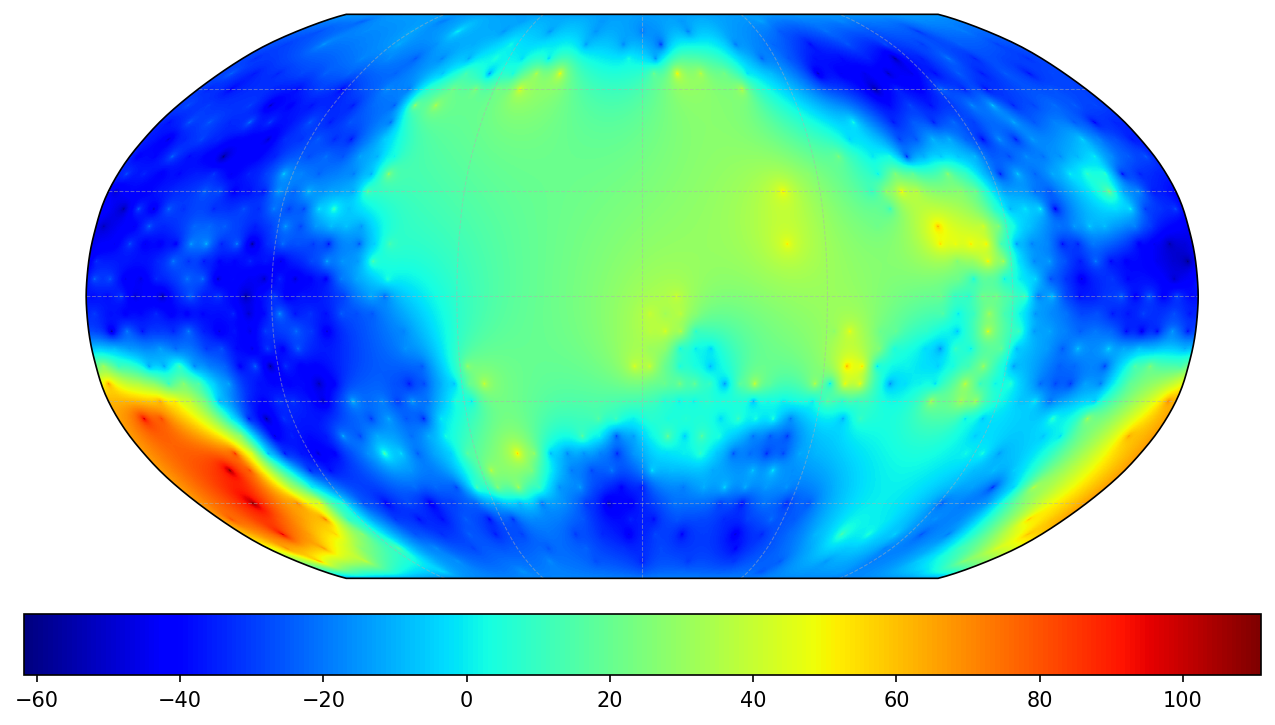

(<Figure size 1500x750 with 2 Axes>, <GeoAxes: >)

In [27]:
carplot(density_xr_anomaly)

In [23]:
G = 6.674e-11# 万有引力常数
R_moon    = bl.Moon2015.mean_radius # 平均半径
R_obs     = R_moon + 11e3           # 观测点高度
porosity  = 0.12                    # 平均孔隙度

'''
R_core    = 370e3         # 内核半径，按实际填
R_mantle  = R_moon-crust_thick         # 月幔外半径（=壳幔界面），按实际填
rho_core  = 6600          # 内核密度 kg/m^3，按实际填
rho_mantle= 3356          # 月幔密度 kg/m^3，按实际填

# 各层质量
M_core    = (4/3) * np.pi * R_core**3 * rho_core
M_mantle  = (4/3) * np.pi * (R_mantle**3 - R_core**3) * rho_mantle
M_total   = M_core + M_mantle

# 在观测高度上的径向重力加速度
g_core    = G * M_core    / R_obs**2
g_mantle  = G * M_mantle  / R_obs**2
g_total   = G * M_total   / R_obs**2

print(f"内核贡献:   {g_core:.6f} m/s^2")
print(f"月幔贡献:   {g_mantle:.6f} m/s^2")
print(f"两层总计:   {g_total:.6f} m/s^2")'''

'\nR_core    = 370e3         # 内核半径，按实际填\nR_mantle  = R_moon-crust_thick         # 月幔外半径（=壳幔界面），按实际填\nrho_core  = 6600          # 内核密度 kg/m^3，按实际填\nrho_mantle= 3356          # 月幔密度 kg/m^3，按实际填\n\n# 各层质量\nM_core    = (4/3) * np.pi * R_core**3 * rho_core\nM_mantle  = (4/3) * np.pi * (R_mantle**3 - R_core**3) * rho_mantle\nM_total   = M_core + M_mantle\n\n# 在观测高度上的径向重力加速度\ng_core    = G * M_core    / R_obs**2\ng_mantle  = G * M_mantle  / R_obs**2\ng_total   = G * M_total   / R_obs**2\n\nprint(f"内核贡献:   {g_core:.6f} m/s^2")\nprint(f"月幔贡献:   {g_mantle:.6f} m/s^2")\nprint(f"两层总计:   {g_total:.6f} m/s^2")'

In [24]:
LON, LAT = np.meshgrid(pot_xr.lon, pot_xr.lat) 
Moon2015_el=bl.Moon2015
gamma=Moon2015_el.normal_gravity(latitude=LAT,height=height)
data=(-pot_xr.radial.data*1e5-gamma)
pot_without_mantlecroe=xr.DataArray(data,dims=('lat','lon'),coords={'lat': pot_xr.lat,'lon': pot_xr.lon})

In [25]:
# 地形贡献
porosity=0.12
bc, r0 = pysh.gravmag.CilmPlusRhoHDH(
    topo_grid.data,
    nmax=8,
    mass=pot.mass,
    rho=density_grid.data * (1 - porosity),
    lmax=lmax
)
bc_coff=pysh.SHGravCoeffs.from_array(bc,gm=bl.Moon2015.geocentric_grav_const, r0=bl.Moon2015.radius)
bc_grid=bc_coff.expand(lmax=lmax,a=R_obs,f=0,extend=False)
bc_raw_xr=bc_grid.to_xarray()
bc_xr=xr.DataArray(-bc_raw_xr.radial.data*1e5,dims=('lat','lon'),coords={'lat': pot_xr.lat,'lon': pot_xr.lon})
pot_without_mantlecroe_bc=xr.DataArray(pot_without_mantlecroe.data-bc_xr.data,dims=('lat','lon'),coords={'lat': pot_xr.lat,'lon': pot_xr.lon})

KeyboardInterrupt: 

In [ ]:
region=(0, 359.99999, -90, 90)
nlat, nlon = pot_without_mantlecroe_bc.shape
shape = (nlat + 1, nlon + 1)
grid_longitude, grid_latitude = vd.grid_coordinates(region=region, shape=(90*2+1,180*2+1))

lon_o=np.sort(np.unique(grid_longitude))
lat_o=np.sort(np.unique(grid_latitude))
lon = 0.5 * (lon_o[:-1] + lon_o[1:])
lat = 0.5 * (lat_o[:-1] + lat_o[1:])
ba_xr2 = pot_without_mantlecroe_bc.sortby("lat")   # 让 lat 从 -90 -> 90
pot_without_mantlecroe_bc_xr_sub=ba_xr2.interp(lat=lat,lon=lon, kwargs={"fill_value": "extrapolate"})
topo_xr2 = topo_xr.sortby("lat")   # 让 lat 从 -90 -> 90
topo_xr_sub=topo_xr2.interp(lat=lat,lon=lon, kwargs={"fill_value": "extrapolate"})
density_xr2 = density_xr_anomaly.sortby("lat")
density_xr_sub=density_xr2.interp(lat=lat,lon=lon, kwargs={"fill_value": "extrapolate"})
density_xr_sub.values=density_xr_sub.values*(1-porosity)
LON, LAT = np.meshgrid(lon, lat)

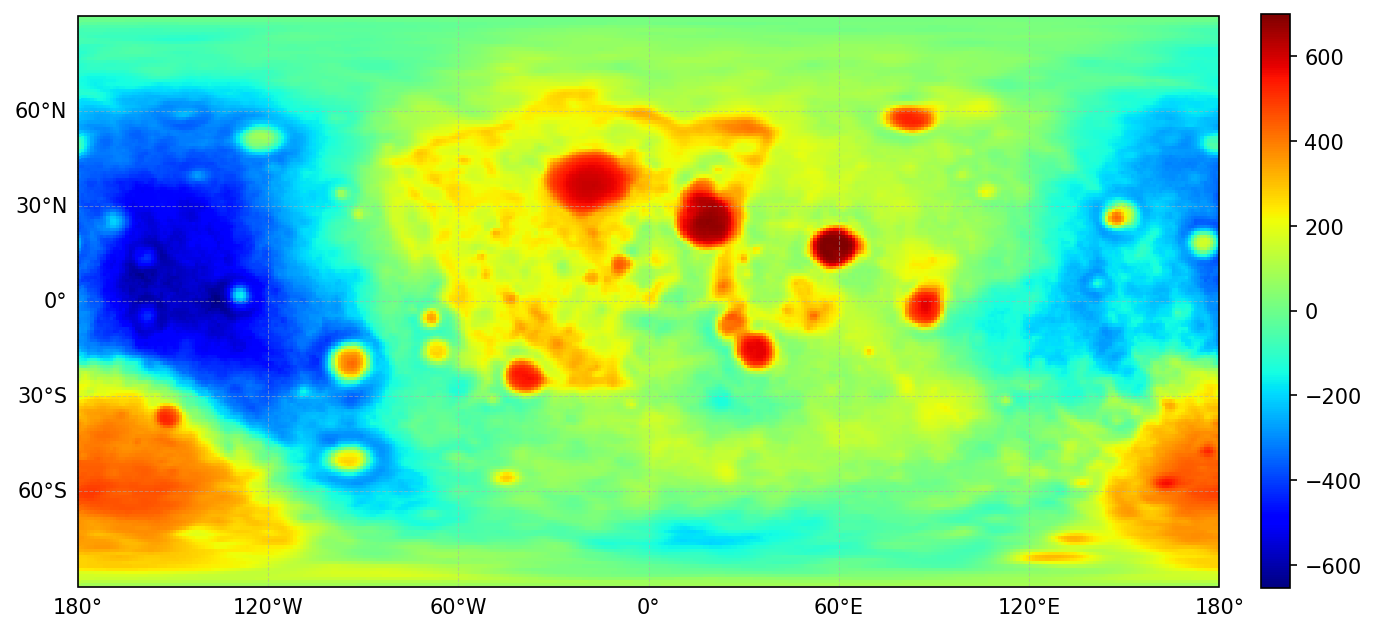

(<Figure size 1500x720 with 2 Axes>, <GeoAxes: >)

In [ ]:
carplot(pot_without_mantlecroe_bc_xr_sub)

In [ ]:
surface=(bl.Moon2015.mean_radius-crust_thick)*np.ones_like(density_xr_sub.values)
reference=(bl.Moon2015.mean_radius)*np.ones_like(density_xr_sub.values)
density_array=density_xr_sub.values 

In [ ]:
mare_layer=hm.tesseroid_layer((lon,lat),surface=surface,reference=reference,properties={"density":density_array})
coordinates=(LON,LAT,R_moon*np.ones_like(surface)+height)
topo_g=mare_layer.tesseroid_layer.gravity(coordinates, field="g_z",progressbar=True)

  0%|          | 0/64800 [00:00<?, ?it/s]

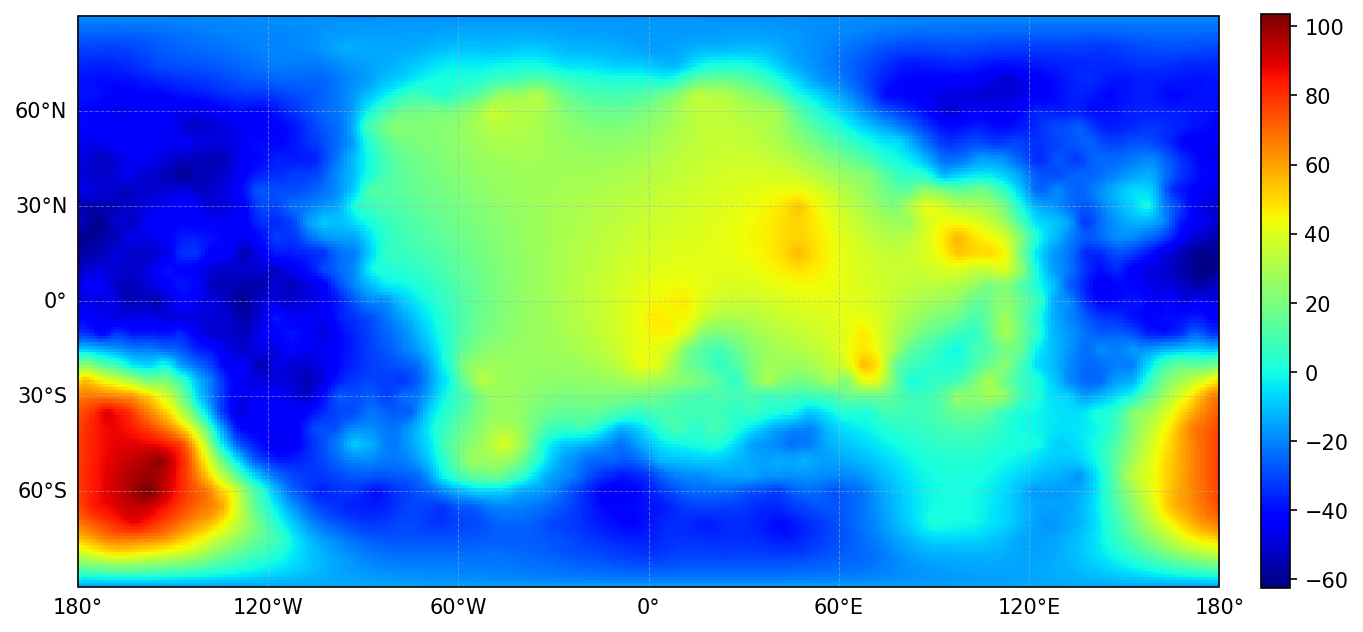

(<Figure size 1500x720 with 2 Axes>, <GeoAxes: >)

In [ ]:
crust_thick_g_da = xr.DataArray(
    topo_g,
    dims=("lat", "lon"),
    coords={
        "lat": lat,
        "lon": lon,
    },
    name="basin_depth"
)
carplot(crust_thick_g_da)

In [ ]:
final_g_da=xr.DataArray(
    pot_without_mantlecroe_bc_xr_sub.values-topo_g,
    dims=("lat", "lon"),
    coords={
        "lat": lat,
        "lon": lon,
    },
    name="basin_depth"
)

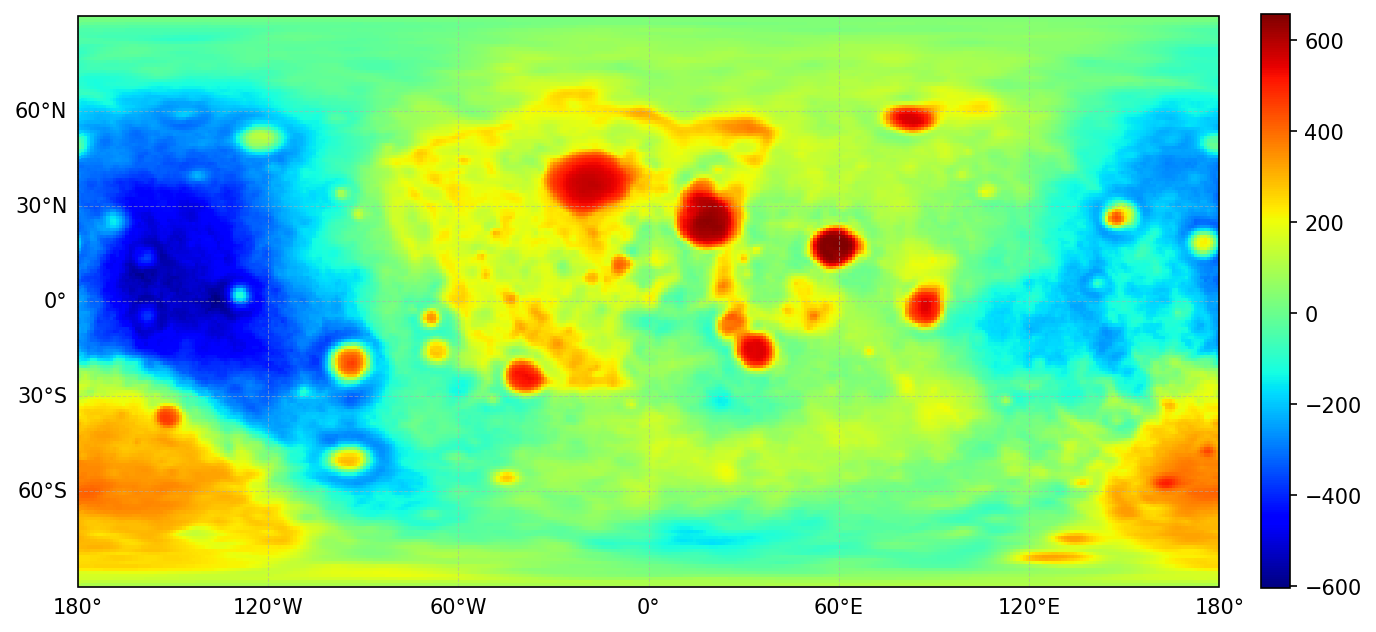

(<Figure size 1500x720 with 2 Axes>, <GeoAxes: >)

In [ ]:
carplot(final_g_da)

In [ ]:
df = (
    final_g_da
    .stack(points=('lat','lon'))
    .reset_index('points')
    .to_dataframe(name='deltaN')
    .reset_index(drop=True)
)

topo_xr_sub.data = topo_xr_sub.data - bl.Moon2015.mean_radius

df_topo = (
    topo_xr_sub
    .stack(points=('lat','lon'))
    .reset_index('points')
    .to_dataframe(name='topo')
    .reset_index(drop=True)
)

df = df.merge(df_topo, on=['lon', 'lat'], how='left')

df.to_csv(result_filename, index=False)

In [ ]:
# Computation complete.
print("Done!")